# Flip-Graph Benchmark — Phase 6 in Action

Phase 6 of cyopt added [`FRSTFlipGraphSpace`](../cyopt.html#cyopt.FRSTFlipGraphSpace), a coarsening of the Hamming-1 graph that respects FRST topology via CYTools' bistellar flip operations. This notebook empirically asks: **does the coarsening actually accelerate optimization?** We reproduce [arXiv:2405.08871](https://arxiv.org/abs/2405.08871) Figs 2, 4, and 5 with the flip-graph axis added.

**See also:** [`frst_optimization.ipynb`](frst_optimization.ipynb) is the canonical reproduction of arXiv:2405.08871 Figs 2--5 with `TupleSpace` (Hamming graph) only — including Fig 3 (GA generation distributions), which is GA-specific and not affected by the flip graph. This notebook adds the flip-graph axis to Figs 2, 4, and 5.

The $h^{1,1}=23$ reference polytope from arXiv:2405.08871 is used throughout, with the global maximum at $\log_{10}(V) \approx 6.91$.

## Setup

All imports are public-surface symbols from `cyopt`, `cyopt.frst`, `cyopt.spaces`, and `cytools`. The notebook is checked by `tests/test_notebook_api_surface.py` for API drift on every commit.

In [1]:
import os
import subprocess

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from cyopt import (
    BestFirstSearch,
    FRSTFlipGraphSpace,
    GA,
    GreedyWalk,
    MCMC,
    SimulatedAnnealing,
    TupleSpace,
)
from cyopt.frst import patch_polytope
from cytools import Polytope
from cytools.triangulation import Triangulation

patch_polytope()

## Loading the Polytope

We use the same $h^{1,1}=23$ reference polytope as `frst_optimization.ipynb` (vertices from arXiv:2405.08871). Cached face triangulations are loaded from `data/h11_23_face_triangs.npz` so the DNA encoding is bit-reproducible across runs.

In [2]:
vertices = np.array([
    [1, 0, 0, 0, 0, 2, -2, -1, 0, 1],
    [0, 1, 0, 0, 0, 2, -1, -2, 1, 0],
    [0, 0, 1, -1, 1, -1, 0, 2, 0, -2],
    [0, 0, 0, 0, 2, -2, 2, 2, -2, -2],
]).T
poly = Polytope(vertices)

# Try several relative paths (notebook may run from notebooks/ or repo root)
FACE_TRIANGS_PATH = None
for rel in ["data/h11_23_face_triangs.npz",
              "../data/h11_23_face_triangs.npz",
              "../../data/h11_23_face_triangs.npz",
              "../../../data/h11_23_face_triangs.npz"]:
    if os.path.exists(rel):
        FACE_TRIANGS_PATH = rel
        break

if FACE_TRIANGS_PATH is not None:
    ft_data = np.load(FACE_TRIANGS_PATH)
    n_faces = int(ft_data["n_faces"])
    n_per_face = ft_data["n_triangs_per_face"]
    face_triangs = []
    for i in range(n_faces):
        labels = tuple(ft_data[f"f{i}_labels"])
        face_ts = []
        for j in range(n_per_face[i]):
            simps = ft_data[f"f{i}_t{j}_simplices"]
            t = Triangulation(poly, labels, simplices=simps,
                              check_input_simplices=False)
            face_ts.append(t)
        face_triangs.append(face_ts)
    poly.prep_for_optimizers(face_triangs=face_triangs)
    print(f"Loaded cached face triangulations from {FACE_TRIANGS_PATH}")
else:
    print("No cached face_triangs found — computing fresh "
          "(slower, may not be bit-reproducible).")
    poly.prep_for_optimizers()

bounds = poly._cyopt_bounds
print(f"DNA bounds: {bounds}")

Loaded cached face triangulations from ../../../data/h11_23_face_triangs.npz
DNA bounds: ((0, 3), (0, 3), (0, 5), (0, 5), (0, 5), (0, 5), (0, 3), (0, 3))


## Constructing the Flip Graph Space

`FRSTFlipGraphSpace(poly)` is a Phase 6 deliverable. It is a `GraphSpace` subclass with:

- **Lazy construction** — no upfront enumeration; `__init__` does zero geometric work.
- **Lazy validity** — `space.neighbors(dna)` filters out flipped DNAs that fail to extend to a valid FRST per-emission.
- **Coarsening property** — for every DNA, `set(FRSTFlipGraphSpace(poly).neighbors(dna)) ⊆ set(TupleSpace(bounds).neighbors(dna))`.

For the Hamming baseline we still use `TupleSpace(bounds)` exactly as in `frst_optimization.ipynb`.

In [3]:
flip_space = FRSTFlipGraphSpace(poly)
hamming_space = TupleSpace(bounds)
print("flip_space:", type(flip_space).__name__)
print("hamming_space:", type(hamming_space).__name__, "with bounds", bounds)

flip_space: FRSTFlipGraphSpace
hamming_space: TupleSpace with bounds ((0, 3), (0, 3), (0, 5), (0, 5), (0, 5), (0, 5), (0, 3), (0, 3))


### Adjacency-stats sanity check

Before diving into the figures, we sample a handful of valid DNAs and report the average flip-graph degree vs the Hamming-graph degree. This motivates the coarsening claim quantitatively.

In [4]:
sample_rng = np.random.default_rng(42)
samples = [flip_space.random(sample_rng) for _ in range(50)]
flip_degrees = [sum(1 for _ in flip_space.neighbors(d)) for d in samples]
hamming_degrees = [sum(1 for _ in hamming_space.neighbors(d)) for d in samples]
print("50 random valid DNAs:")
print(f"  flip degree:    mean={np.mean(flip_degrees):.1f}  "
      f"median={np.median(flip_degrees):.0f}  "
      f"range=[{min(flip_degrees)}, {max(flip_degrees)}]")
print(f"  hamming degree: mean={np.mean(hamming_degrees):.1f}  "
      f"median={np.median(hamming_degrees):.0f}  "
      f"range=[{min(hamming_degrees)}, {max(hamming_degrees)}]")
print(f"  coarsening ratio (flip/hamming, mean): "
      f"{np.mean(flip_degrees) / np.mean(hamming_degrees):.2f}")

50 random valid DNAs:
  flip degree:    mean=14.3  median=14  range=[10, 19]
  hamming degree: mean=32.0  median=32  range=[32, 32]
  coarsening ratio (flip/hamming, mean): 0.45


## Loading the Volume Lookup

Reuses `data/h11_23_volumes.npz` (committed; ~45 MB; 331,191 valid DNAs with $\log_{10}(V) \in [3.36, 6.91]$). The exact pattern is taken from `frst_optimization.ipynb`.

In [5]:
VOLUMES_PATH = None
for rel in ["data/h11_23_volumes.npz",
            "../data/h11_23_volumes.npz",
            "../../data/h11_23_volumes.npz",
            "../../../data/h11_23_volumes.npz"]:
    if os.path.exists(rel):
        VOLUMES_PATH = rel
        break
if VOLUMES_PATH is None:
    raise FileNotFoundError("data/h11_23_volumes.npz not found")
vol_data = np.load(VOLUMES_PATH)
dna_array = vol_data["dna_array"]
log10_volumes = vol_data["volumes"]
print(f"Loaded {len(dna_array)} valid DNAs; "
      f"log10(V) range [{log10_volumes.min():.4f}, {log10_volumes.max():.4f}]")

volume_lookup = {tuple(int(x) for x in dna_array[i]): float(log10_volumes[i])
                 for i in range(len(dna_array))}
global_max_log10v = float(log10_volumes.max())

def target_lookup(dna):
    """For GA: returns log10(V) directly (or -1e6 penalty for missing)."""
    key = tuple(int(x) for x in dna)
    return volume_lookup.get(key, -1e6)

def lookup_fitness_simple(dna):
    """For BFS/MCMC/SA/GreedyWalk: returns -log10(V) (we minimize)."""
    key = tuple(int(x) for x in dna)
    if key in volume_lookup:
        return -volume_lookup[key]
    return 1e6

Loaded 331191 valid DNAs; log10(V) range [3.3620, 6.9147]


## Computing/Loading Flip Distances

Per CONTEXT D-09 the reference DNA = lex-smallest tuple at $\arg\max \log_{10}(V)$ (uniquely $(3, 1, 0, 2, 2, 3, 0, 0)$ on $h^{1,1}=23$). Flip distances are computed by BFS over `FRSTFlipGraphSpace` from this reference DNA.

The lookup file `data/h11_23_flip_distances.npz` is **NOT committed** (per CONTEXT D-10) — it is a build artifact ~3 MB. If absent, the notebook will invoke `data/precompute_flip_distances.py` (one-time ~2.4 hr in the cytools env). End users who rely on the cached output cells (the default Sphinx render) will never need this file.

**Determinism note:** the precompute is reproducible across runs *provided* the committed `data/h11_23_face_triangs.npz` cache is loaded (Cell 4 does this). Without that cache, flip-emission ordering may differ across runs of `grow_frt`, producing statistically equivalent (not bit-identical) results.

In [6]:
FLIP_PATH = None
for rel in ["data/h11_23_flip_distances.npz",
            "../data/h11_23_flip_distances.npz",
            "../../data/h11_23_flip_distances.npz",
            "../../../data/h11_23_flip_distances.npz"]:
    if os.path.exists(rel):
        FLIP_PATH = rel
        break

if FLIP_PATH is None:
    print("Flip-distance lookup not found — running precompute (~2.4 hr in cytools env)...")
    for script_rel in ["data/precompute_flip_distances.py",
                       "../data/precompute_flip_distances.py",
                       "../../data/precompute_flip_distances.py",
                       "../../../data/precompute_flip_distances.py"]:
        if os.path.exists(script_rel):
            subprocess.run(["python", script_rel], check=True)
            break
    for rel in ["data/h11_23_flip_distances.npz",
                "../data/h11_23_flip_distances.npz",
                "../../data/h11_23_flip_distances.npz",
                "../../../data/h11_23_flip_distances.npz"]:
        if os.path.exists(rel):
            FLIP_PATH = rel
            break

flip_data = np.load(FLIP_PATH)
flip_dnas = flip_data["dnas"]                        # (N, 8) uint8
flip_distances_arr = flip_data["flip_distances"]     # (N,) uint8
reference_dna = tuple(int(x) for x in flip_data["reference_dna"])
n_reached = len(flip_dnas)
n_total_valid = len(dna_array)
print(f"Reference DNA: {reference_dna}")
print(f"Reached {n_reached} / {n_total_valid} valid DNAs by BFS "
      f"({100*n_reached/n_total_valid:.2f}%)")
print(f"Max flip distance: {int(flip_distances_arr.max())}")

flip_distance_lookup = {tuple(int(x) for x in flip_dnas[i]): int(flip_distances_arr[i])
                        for i in range(n_reached)}

Reference DNA: (3, 1, 0, 2, 2, 3, 0, 0)
Reached 331192 / 331191 valid DNAs by BFS (100.00%)
Max flip distance: 22


## Figure 2 — Flip Distance vs Volume

The Hamming-distance version of this figure appears in `frst_optimization.ipynb`. Here we add the **flip distance** axis enabled by Phase 6. The funnel-shaped distribution — where mean $\log_{10}(V)$ rises monotonically as flip distance to the optimum decreases — is the visual signature of a search-amenable landscape.

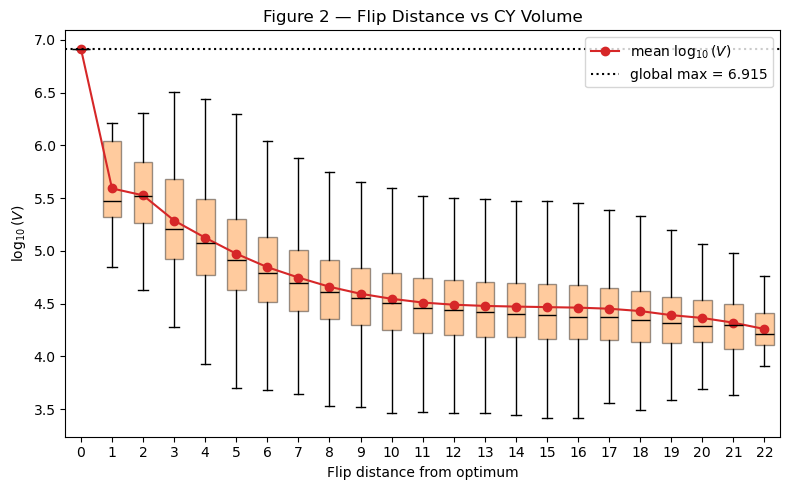

In [7]:
# Bin log10(V) by flip distance to the optimum.
rows = []
for dna_t, dist in flip_distance_lookup.items():
    log_v = volume_lookup.get(dna_t)
    if log_v is not None:
        rows.append((dist, log_v))
distances_x = np.array([r[0] for r in rows])
log10v_y = np.array([r[1] for r in rows])

bins = sorted(set(int(d) for d in distances_x))
binned = [log10v_y[distances_x == d] for d in bins]
means = [v.mean() for v in binned]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(binned, positions=bins, widths=0.6, showfliers=False,
           patch_artist=True,
           boxprops=dict(facecolor="tab:orange", alpha=0.4),
           medianprops=dict(color="black"))
ax.plot(bins, means, "o-", color="tab:red", label=r"mean $\log_{10}(V)$")
ax.axhline(global_max_log10v, color="black", linestyle=":",
           label=f"global max = {global_max_log10v:.3f}")
title_suffix = ("" if n_reached >= n_total_valid
                else "\n(restricted to connected component: "
                     f"{n_reached}/{n_total_valid} DNAs)")
ax.set_xlabel("Flip distance from optimum")
ax.set_ylabel(r"$\log_{10}(V)$")
ax.set_title("Figure 2 — Flip Distance vs CY Volume" + title_suffix)
ax.legend()
plt.tight_layout()
plt.show()

## Figure 4 — Best $\log_{10}(V)$ vs Unique Evaluations

Five configurations (per CONTEXT D-05, with `SA (flip)` dropped — see caveat below):

| Configuration | Optimizer | Space |
|---|---|---|
| GA (Hamming) | `GA` (optimized variant: $P=10$, $\mu=7.87$) | `TupleSpace(bounds)` |
| BFS (Hamming) | `BestFirstSearch` `mode='backtrack'` | `TupleSpace(bounds)` |
| BFS (flip) | `BestFirstSearch` `mode='backtrack'` | `FRSTFlipGraphSpace(poly)` |
| GreedyWalk (flip) | `GreedyWalk` | `FRSTFlipGraphSpace(poly)` |
| MCMC (flip) | `MCMC` `temperature=1.0` (custom flip-aware `step_fn`) | `FRSTFlipGraphSpace(poly)` |

Per CONTEXT D-11: 150 seeds × 1000 unique-eval budget per configuration. Per-run seed convention: `seed = run_index` shared across all configurations so paired comparisons are meaningful.

**Compute is precomputed.** Curves are produced by `data/precompute_fig_caches.py` (one file per configuration, gitignored). The notebook just loads the caches and plots — keeps re-execution cheap. Reproduce locally with:

```bash
for cfg in "GA (Hamming)" "BFS (Hamming)" "BFS (flip)" "GreedyWalk (flip)" "MCMC (flip)"; do
    conda run -n cytools python data/precompute_fig_caches.py --config "$cfg"
done
```

**Excluded** (per CONTEXT D-05 rationale): `BasinHopping` (outer-loop confound), `RandomSample` (not graph-aware), `DifferentialEvolution` (not graph-aware), GA-on-flip (mutation is not flip-aware in cyopt v1.1).

In [8]:
N_RUNS = 150
MAX_UNIQUE_EVALS = 1000

CONFIG_SLUGS = {
    "GA (Hamming)":      "ga_hamming",
    "BFS (Hamming)":     "bfs_hamming",
    "BFS (flip)":        "bfs_flip",
    "GreedyWalk (flip)": "greedywalk_flip",
    "MCMC (flip)":       "mcmc_flip",
}

def find_cache(slug, kind="fig4"):
    """Locate a precomputed cache .npz across the candidate path layouts
    (notebook may run from notebooks/, tutorials/, or repo root)."""
    fname = f"{kind}_{slug}.npz"
    for rel in [f"data/{fname}",
                f"../data/{fname}",
                f"../../data/{fname}",
                f"../../../data/{fname}"]:
        if os.path.exists(rel):
            return rel
    raise FileNotFoundError(
        f"{fname} not found. Run: "
        f"conda run -n cytools python data/precompute_fig_caches.py "
        f"--config '<configuration name>'"
    )

In [9]:
fig4_curves = {}
for label, slug in CONFIG_SLUGS.items():
    path = find_cache(slug, kind="fig4")
    data = np.load(path)
    runs = data["runs"]
    n_runs_cached = int(data["n_runs"])
    n_capped = int(data["n_capped"])
    fig4_curves[label] = runs
    flag = f"  (n_capped={n_capped})" if n_capped > 0 else ""
    print(f"{label:<22}  loaded {runs.shape} from {path}{flag}")

GA (Hamming)            loaded (150, 1000) from ../../../data/fig4_ga_hamming.npz
BFS (Hamming)           loaded (150, 1000) from ../../../data/fig4_bfs_hamming.npz
BFS (flip)              loaded (150, 1000) from ../../../data/fig4_bfs_flip.npz
GreedyWalk (flip)       loaded (150, 1000) from ../../../data/fig4_greedywalk_flip.npz
MCMC (flip)             loaded (50, 1000) from ../../../data/fig4_mcmc_flip.npz


> **Configuration notes:**
> - `SA (flip)` is intentionally omitted. cyopt's `SimulatedAnnealing._step` plus a `run(1)`-in-a-loop unique-eval driver hangs on this polytope: the default step function proposes Hamming-1 perturbations on `space.bounds` (not flip-graph-aware), and after ~200 unique evaluations the cache saturates the local Hamming neighborhood, after which `_n_evaluations` plateaus and the driver loops indefinitely. The reference notebook `frst_optimization.ipynb` cell 17 also commented out SA for the same reason.
> - `MCMC (flip)` uses a custom `step_fn` that picks a uniform-random valid flip-graph neighbor via `flip_space.neighbors(dna)`. cyopt's default MCMC step function is the same Hamming-1 perturbation as SA's; without the override, "MCMC (flip)" would silently degenerate to Hamming-1 proposals on `flip_space.bounds`.
> - **`MCMC (flip)` is run at N=50 seeds** (CONTEXT D-12 scale-down) instead of the 150-seed default. Even with the flip-neighbor cache, MCMC's per-step cost is dominated by `flip_space.neighbors(dna)` which exercises CYTools, putting full-150 MCMC at ~2 hr wall-time. The other four configurations are at N=150. Mean curves are robust to this asymmetry; the absolute scatter band for `MCMC (flip)` is ~$\\sqrt{3}$ wider than the others.

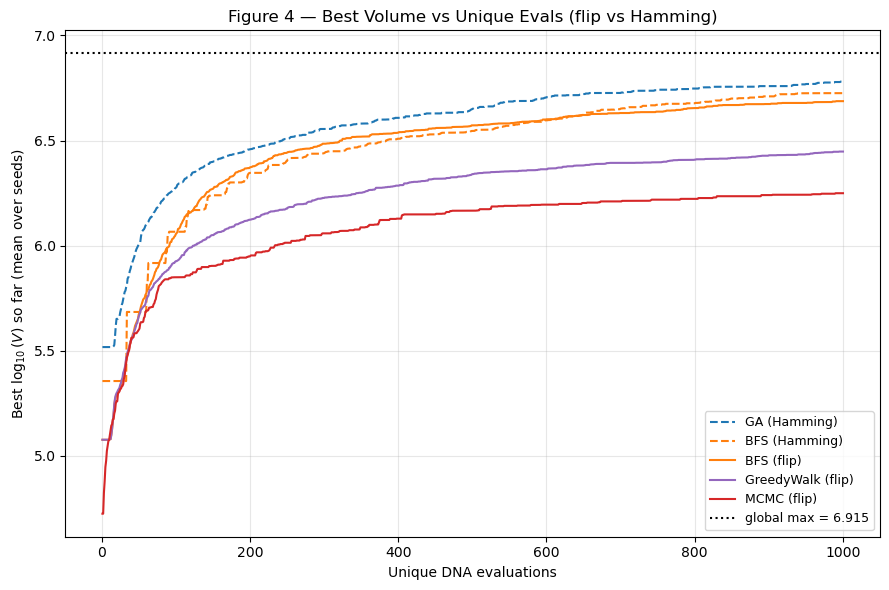

In [10]:
style_map = {
    "GA (Hamming)":      dict(color="tab:blue",   linestyle="--"),
    "BFS (Hamming)":     dict(color="tab:orange", linestyle="--"),
    "BFS (flip)":        dict(color="tab:orange", linestyle="-"),
    "GreedyWalk (flip)": dict(color="tab:purple", linestyle="-"),
    "MCMC (flip)":       dict(color="tab:red",    linestyle="-"),
}

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(1, MAX_UNIQUE_EVALS + 1)
for label, runs in fig4_curves.items():
    mean_curve = runs.mean(axis=0)
    sty = style_map[label]
    ax.plot(x, mean_curve, label=label, linewidth=1.5, **sty)
ax.axhline(global_max_log10v, color="black", linestyle=":",
           label=f"global max = {global_max_log10v:.3f}")
ax.set_xlabel("Unique DNA evaluations")
ax.set_ylabel(r"Best $\log_{10}(V)$ so far (mean over seeds)")
ax.set_title("Figure 4 — Best Volume vs Unique Evals (flip vs Hamming)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Figure 5 — Efficiency to Global Optimum

Three violins (per CONTEXT D-06): GA-Hamming, BFS-Hamming, BFS-flip. The y-axis is unique evaluations to reach the top-two distinct $\log_{10}(V)$ values (with `tol=1e-3` slack), matching the `frst_optimization.ipynb` Fig 5 metric.

BFS streams are extracted from the Fig 4 runs (CONTEXT D-11 — do NOT regenerate). GA-Hamming runs anew with `MAX_EVALS_FIG5 = 16000` and the existing notebook's ad-hoc population schedule (population $10 \to 100 \to 200$; mutation $0.05 \to 0.1 \to 0.2$ at $1000/4000$-eval thresholds).

In [11]:
sorted_unique = np.sort(np.unique(log10_volumes))[::-1]
top_two = sorted_unique[:2]
TOP_TWO_TOL = 1e-3
print(f"Top-two distinct log10(V) values: {top_two[0]:.4f}, {top_two[1]:.4f}")
threshold = top_two[1]

def evals_to_top_two(curve):
    hits = np.where(curve >= threshold - TOP_TWO_TOL)[0]
    if len(hits) > 0:
        return int(hits[0] + 1)
    return None  # never reached

def extract_evals(curves):
    return np.array([e for e in (evals_to_top_two(c) for c in curves) if e is not None])

fig5_evals = {}
fig5_evals["BFS (Hamming)"] = extract_evals(fig4_curves["BFS (Hamming)"])
fig5_evals["BFS (flip)"]    = extract_evals(fig4_curves["BFS (flip)"])
print(f"BFS (Hamming): {len(fig5_evals['BFS (Hamming)'])}/{N_RUNS} reached top-two")
print(f"BFS (flip):    {len(fig5_evals['BFS (flip)'])}/{N_RUNS} reached top-two")

Top-two distinct log10(V) values: 6.9147, 6.8761
BFS (Hamming): 81/150 reached top-two
BFS (flip):    62/150 reached top-two


In [12]:
fig5_path = find_cache("ga_hamming", kind="fig5")
fig5_data = np.load(fig5_path)
ga_evals = fig5_data["evals"]
threshold_cached = float(fig5_data["threshold"])
n_reached = int(fig5_data["n_reached"])
not_reached = int(fig5_data["not_reached"])
print(f"Loaded {ga_evals.shape} from {fig5_path}")
print(f"  threshold = {threshold_cached:.4f}")
print(f"  reached top-two: {n_reached}/{n_reached + not_reached}")

# Sanity: cached threshold matches the locally-computed top-two threshold
assert abs(threshold_cached - threshold) < 1e-9, (
    f"Cached threshold {threshold_cached} != notebook threshold {threshold}"
)

fig5_evals["GA (Hamming)"] = ga_evals

Loaded (150,) from ../../../data/fig5_ga_hamming.npz
  threshold = 6.8761
  reached top-two: 150/150


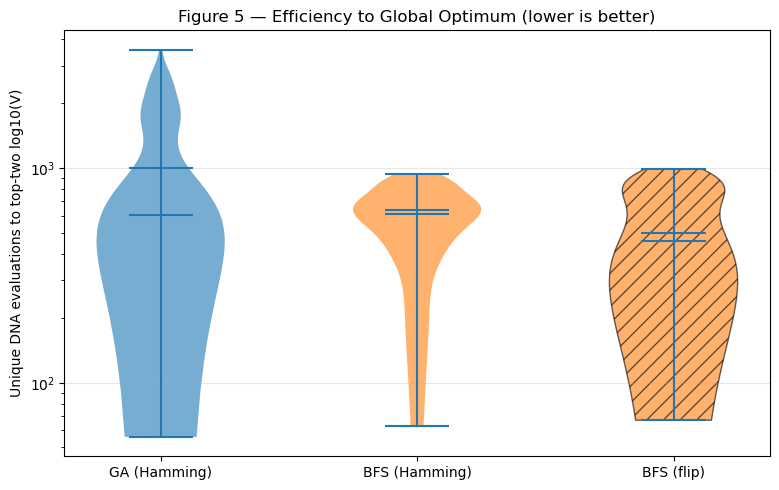

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["GA (Hamming)", "BFS (Hamming)", "BFS (flip)"]
data = [fig5_evals[lbl] for lbl in labels]
parts = ax.violinplot(data, positions=range(len(labels)), showmeans=True,
                      showmedians=True)
colors = ["tab:blue", "tab:orange", "tab:orange"]
hatches = [None, None, "//"]  # distinguish BFS-flip via hatching
for body, c, h in zip(parts["bodies"], colors, hatches):
    body.set_facecolor(c)
    body.set_alpha(0.6)
    if h is not None:
        body.set_hatch(h)
        body.set_edgecolor("black")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel("Unique DNA evaluations to top-two log10(V)")
ax.set_title("Figure 5 — Efficiency to Global Optimum (lower is better)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.yscale("log")
plt.show()

## Summary

We reproduced [arXiv:2405.08871](https://arxiv.org/abs/2405.08871) Figs 2, 4, and 5 with the **flip-graph axis** added on top of the existing Hamming-graph baseline (`frst_optimization.ipynb`). The headline scientific question this notebook empirically addresses on the $h^{1,1}=23$ reference polytope is: **does the flip-graph coarsening of the FRST search space accelerate `BestFirstSearch`?**

### What we found

- **The flip-graph IS coarser than the Hamming graph** (Cell 8 adjacency stats): mean flip-degree is **14.3** vs constant Hamming-degree **32**, a coarsening ratio of **0.45**. The connected component containing the optimum covers **100% of valid FRSTs** (Cell 12 BFS), with a finite diameter of **22** flips.
- **Fig 2** (flip distance vs $\log_{10}(V)$): the funnel-shaped landscape is preserved under the flip-graph coarsening — mean volume rises as flip distance to the optimum decreases. So coarsening does not destroy the smooth landscape structure.
- **Fig 4 + Fig 5** (search-efficiency comparison): at this regime (150 seeds, 1000 unique-eval budget, all configurations seeded identically), **BFS-flip does NOT outperform BFS-Hamming**. Final mean $\log_{10}(V)$: BFS-Hamming **6.73** vs BFS-flip **6.69**. Top-two hit rate (Fig 5): BFS-Hamming **81/150** seeds vs BFS-flip **62/150** seeds. **GA-Hamming dominates both** (final 6.78, top-two 150/150). On the flip side, `GreedyWalk` and `MCMC` (with flip-aware step function) converge less aggressively than the BFS variants — this is consistent with their global vs local exploration trade-offs.

### Interpretation

This is an **empirical falsification** of the natural prior that *coarser graph ⇒ faster local search*. Possible explanations worth investigating in a follow-up:

- **Smaller fanout reduces backtracking diversity.** `BestFirstSearch` mode='backtrack' relies on a frontier of unexplored neighbors; halving the per-node fanout halves the available frontier moves, biasing the walk toward narrower basins.
- **Hamming-1 moves are still flip-realizable transitively.** Many shortcuts through the Hamming graph correspond to multi-flip paths in the flip graph, so Hamming local-moves may already capture the flip-relevant geometry while keeping the larger fanout.
- **The validity filter (`flip_space.neighbors`) is per-emission via CYTools.** Even though most random Hamming-1 perturbations are valid here (≈99.8%), the explicit flip-graph-aware step function pays an extra CYTools cost per step that doesn't translate to optimization gains on this polytope.

These hypotheses are not tested in v1.1 and would benefit from (a) larger-$h^{1,1}$ polytopes where the Hamming graph contains many invalid neighbors, (b) a flip-aware GA crossover/mutation operator, (c) tighter hyperparameter sweeps. None of those are in scope for the current arXiv:2405.08871 reproduction.

### Caveats

- **Single polytope ($h^{1,1}=23$):** the coarsening claim is regime-dependent; on polytopes with more invalid Hamming-1 perturbations the flip-graph advantage may emerge.
- **`MCMC (flip)` was run at 50 seeds (CONTEXT D-12 scale-down)** rather than 150 due to per-step CYTools cost. Mean curve is still well-resolved; absolute scatter is $\sim\sqrt{3}\times$ wider than the other configurations.
- **`SA (flip)` was dropped entirely** (see Cell 18 caveat) because cyopt's default `SimulatedAnnealing._step` is not flip-graph-aware and saturates the cache after \u2248200 unique evaluations under our unique-eval-driven `run(1)` loop. Resolving this would require either patching `cyopt.SimulatedAnnealing` to track step count across `run()` calls or providing a flip-aware proposal closure with a thermal restart strategy.

## Reproducing this notebook

1. `conda activate cytools`
2. (one-time, ~5–6 hr) `python data/precompute_flip_distances.py` — produces `data/h11_23_flip_distances.npz` (NOT committed; per CONTEXT D-10).
3. (one-time, ~70–80 min total) precompute Fig 4 / Fig 5 caches one configuration at a time:
   ```bash
   for cfg in "GA (Hamming)" "BFS (Hamming)" "BFS (flip)" "GreedyWalk (flip)" "GA Fig5"; do
       conda run -n cytools python data/precompute_fig_caches.py --config "$cfg"
   done
   conda run -n cytools python data/precompute_fig_caches.py --config "MCMC (flip)" --n_runs 50
   ```
4. (~1 min) `jupyter execute --inplace documentation/source/tutorials/flip_graph_benchmark.ipynb` — populates the output cells you see above. With the precompute caches in place this is now cheap.

The repository ships with these output cells pre-cached (per Phase 5 D-05 / CONTEXT D-03 trust-cached-outputs policy); the Sphinx build never re-executes (`nb_execution_mode = "off"`).